# spaCI : deciphering spatial cellular communication through adaptive graph model on micoenvironment samples

### Import packages

In [2]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt

### Read the files

In [3]:
base_dir = "/home/akram/share/Multiple_Grids/spaCI"

n_grids = 20
pred_threshold = 0.5

output_dir = os.path.join(base_dir, "summary_results")
os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: /home/akram/share/Multiple_Grids/spaCI/summary_results


### Loop over all grids and build per-grid spaCI matrices

In [6]:
# Store all interaction matrices
all_interaction_matrices = []

# Store all filtered predict.csv rows
all_predict_dfs = []

# Store grid metadata
grid_metadata = []


for grid_id in range(1, n_grids + 1):

    print("\n" + "="*70)
    print(f"Processing Grid {grid_id}")
    print("="*70)

    counts_path = os.path.join(
        base_dir,
        f"Grid_{grid_id}_counts.csv"
    )

    meta_path = os.path.join(
        base_dir,
        f"Grid_{grid_id}_meta.csv"
    )

    pred_path = os.path.join(
        base_dir,
        f"Grid_{grid_id}",
        "results",
        "predict.csv"
    )

    # ────────────────────────────────────────
    # Check required files
    # ────────────────────────────────────────
    if not os.path.exists(counts_path):
        print(f"Missing counts file: {counts_path}")
        continue

    if not os.path.exists(meta_path):
        print(f"Missing meta file: {meta_path}")
        continue

    if not os.path.exists(pred_path):
        print(f"Missing predict file: {pred_path}")
        continue

    # ────────────────────────────────────────
    # Read files
    # ────────────────────────────────────────
    lr_df = pd.read_csv(pred_path)
    meta_df = pd.read_csv(meta_path, index_col=0)
    expr = pd.read_csv(counts_path, index_col=0)

    # Ensure names are strings
    expr.index = expr.index.astype(str)
    expr.columns = expr.columns.astype(str)
    meta_df.index = meta_df.index.astype(str)

    # ────────────────────────────────────────
    # Identify cell type column
    # ────────────────────────────────────────
    if "type" in meta_df.columns:
        celltype_col = "type"
    elif "celltype" in meta_df.columns:
        celltype_col = "celltype"
    else:
        raise ValueError(
            f"Grid {grid_id}: meta file must contain 'type' or 'celltype'"
        )

    meta_df[celltype_col] = meta_df[celltype_col].astype(str)

    # ────────────────────────────────────────
    # Keep only predicted LR interactions
    # ────────────────────────────────────────
    lr_df = lr_df[lr_df["pred"] > pred_threshold].copy()

    if lr_df.empty:
        print(f"No LR pairs above threshold in Grid {grid_id}")
        continue

    # Add grid ID to predict results
    lr_df["grid_id"] = grid_id

    # Store all predictions
    all_predict_dfs.append(lr_df.copy())

    # ────────────────────────────────────────
    # Grid metadata
    # ────────────────────────────────────────
    cell_types = sorted(meta_df[celltype_col].unique())

    grid_metadata.append({
        "grid_id": grid_id,
        "n_cells": meta_df.shape[0],
        "n_distinct_celltypes": len(cell_types),
        "celltypes_present": ", ".join(cell_types),
        "n_predicted_lr_pairs": lr_df[["ligand", "receptor"]].drop_duplicates().shape[0],
        "n_prediction_rows": lr_df.shape[0]
    })

    print("Number of cells:", meta_df.shape[0])
    print("Number of cell types:", len(cell_types))
    print("Number of predicted LR pairs:", lr_df[["ligand", "receptor"]].drop_duplicates().shape[0])

    # ────────────────────────────────────────
    # Group cells by cell type
    # ────────────────────────────────────────
    cell_groups = {
        ct: meta_df[meta_df[celltype_col] == ct].index.tolist()
        for ct in cell_types
    }

    # ────────────────────────────────────────
    # Compute mean expression per gene per cell type
    # ────────────────────────────────────────
    gene_avg_expr = defaultdict(lambda: defaultdict(float))

    lr_genes = pd.concat([
        lr_df["ligand"].astype(str),
        lr_df["receptor"].astype(str)
    ]).unique()

    for gene in lr_genes:

        if gene in expr.index:

            for ct, cells in cell_groups.items():

                valid_cells = expr.columns.intersection(cells)

                if len(valid_cells) > 0:
                    vals = expr.loc[gene, valid_cells]
                    gene_avg_expr[gene][ct] = vals.mean()
                else:
                    gene_avg_expr[gene][ct] = 0.0

        else:
            print(f"[Warning] Gene {gene} not in expression matrix for Grid {grid_id}")

    # ────────────────────────────────────────
    # Build interaction matrix for this grid
    # ────────────────────────────────────────
    interaction_matrix = pd.DataFrame(
        0.0,
        index=cell_types,
        columns=cell_types
    )

    for _, row in lr_df.iterrows():

        lig = str(row["ligand"])
        rec = str(row["receptor"])

        for sender in cell_types:
            for receiver in cell_types:

                lig_expr = gene_avg_expr[lig].get(sender, 0.0)
                rec_expr = gene_avg_expr[rec].get(receiver, 0.0)

                interaction_matrix.loc[sender, receiver] += lig_expr * rec_expr

    # ────────────────────────────────────────
    # Save per-grid matrix
    # ────────────────────────────────────────
    matrix_path = os.path.join(
        output_dir,
        f"spaCI_interaction_matrix_Grid_{grid_id}.csv"
    )

    interaction_matrix.to_csv(matrix_path)

    print("Saved matrix:", matrix_path)

    all_interaction_matrices.append(interaction_matrix)


Processing Grid 1
Number of cells: 2812
Number of cell types: 18
Number of predicted LR pairs: 44
Saved matrix: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_interaction_matrix_Grid_1.csv

Processing Grid 2
Number of cells: 2249
Number of cell types: 13
Number of predicted LR pairs: 43
Saved matrix: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_interaction_matrix_Grid_2.csv

Processing Grid 3
Number of cells: 3635
Number of cell types: 15
Number of predicted LR pairs: 44
Saved matrix: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_interaction_matrix_Grid_3.csv

Processing Grid 4
Number of cells: 2434
Number of cell types: 13
Number of predicted LR pairs: 43
Saved matrix: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_interaction_matrix_Grid_4.csv

Processing Grid 5
Number of cells: 1019
Number of cell types: 15
Number of predicted LR pairs: 42
Saved matrix: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_interactio

### Save all prediction files combined

In [7]:
if len(all_predict_dfs) > 0:

    all_predictions_df = pd.concat(
        all_predict_dfs,
        ignore_index=True
    )

    all_predictions_path = os.path.join(
        output_dir,
        "spaCI_all_predictions_ALL_GRIDS.csv"
    )

    all_predictions_df.to_csv(all_predictions_path, index=False)

    print("Saved all spaCI predictions:")
    print(all_predictions_path)

    display(all_predictions_df.head())

else:
    raise ValueError("No predicted LR pairs were found across grids.")

Saved all spaCI predictions:
/home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_all_predictions_ALL_GRIDS.csv


,ligand,receptor,truelabel,pred,grid_id
0,B2M,CD3G,1,0.9894,1
1,B2M,KLRD1,1,0.9885,1
2,C3,CD19,1,0.9961,1
3,C3,IFITM1,1,0.9958,1
4,C3,ITGAM,1,0.9925,1


### Save distinct LR pairs across all grids

In [8]:
lr_summary = (
    all_predictions_df
    .groupby(["ligand", "receptor"])
    .agg({
        "grid_id": lambda x: sorted(set(x)),
        "pred": ["mean", "max", "count"]
    })
)

# Flatten columns
lr_summary.columns = [
    "grids_present",
    "mean_pred_score",
    "max_pred_score",
    "n_occurrences"
]

lr_summary["n_grids_present"] = (
    lr_summary["grids_present"].apply(len)
)

lr_summary["grid_frequency"] = (
    lr_summary["n_grids_present"] / n_grids
)

lr_summary = lr_summary.reset_index()

lr_summary["LR_pair"] = (
    lr_summary["ligand"].astype(str) + "_" +
    lr_summary["receptor"].astype(str)
)

lr_summary = lr_summary.sort_values(
    by=["n_grids_present", "mean_pred_score"],
    ascending=[False, False]
)

lr_summary_path = os.path.join(
    output_dir,
    "spaCI_distinct_LR_pairs_across_ALL_GRIDS.csv"
)

lr_summary.to_csv(lr_summary_path, index=False)

print("Saved distinct LR-pair summary:")
print(lr_summary_path)

display(lr_summary.head(20))

Saved distinct LR-pair summary:
/home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_distinct_LR_pairs_across_ALL_GRIDS.csv


,ligand,receptor,grids_present,mean_pred_score,max_pred_score,n_occurrences,n_grids_present,grid_frequency,LR_pair
9,CXCL1,CXCR2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.999305,0.9998,20,20,1.0,CXCL1_CXCR2
10,CXCL16,CXCR6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.999255,1.0000,20,20,1.0,CXCL16_CXCR6
24,PF4,CXCR3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.998915,0.9999,20,20,1.0,PF4_CXCR3
14,FGF2,SDC1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.998195,0.9995,20,20,1.0,FGF2_SDC1
12,FGF2,CD44,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.997545,0.9997,20,20,1.0,FGF2_CD44
5,CCL5,CCR4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.997455,0.9997,20,20,1.0,CCL5_CCR4
7,CCL5,SDC1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.997215,0.9995,20,20,1.0,CCL5_SDC1
8,CD274,PDCD1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.996840,0.9998,20,20,1.0,CD274_PDCD1
6,CCL5,CXCR3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.996785,0.9998,20,20,1.0,CCL5_CXCR3
30,THBS1,SDC1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.991700,0.9999,20,20,1.0,THBS1_SDC1


###  Save grid metadata summary

In [9]:
grid_metadata_df = pd.DataFrame(grid_metadata)

grid_metadata_df = grid_metadata_df.sort_values(
    by="grid_id",
    ascending=True
).reset_index(drop=True)

grid_metadata_path = os.path.join(
    output_dir,
    "spaCI_grid_metadata_summary.csv"
)

grid_metadata_df.to_csv(grid_metadata_path, index=False)

print("Saved grid metadata:")
print(grid_metadata_path)

display(grid_metadata_df)

Saved grid metadata:
/home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_grid_metadata_summary.csv


,grid_id,n_cells,n_distinct_celltypes,celltypes_present,n_predicted_lr_pairs,n_prediction_rows
0,1,2812,18,"Astrocyte, B cell, Endothelial, Ependymal, Mac...",44,44
1,2,2249,13,"Astrocyte, B cell, Endothelial, Macrophage, Mi...",43,43
2,3,3635,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi...",44,44
3,4,2434,13,"Astrocyte, B cell, Endothelial, Macrophage, Mi...",43,43
4,5,1019,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi...",42,42
5,6,534,13,"Astrocyte, Endothelial, Macrophage, Microglia,...",44,44
6,7,2557,14,"Astrocyte, Endothelial, Macrophage, Microglia,...",38,38
7,8,1986,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi...",44,44
8,9,2454,15,"Astrocyte, Endothelial, Ependymal, Macrophage,...",42,42
9,10,1848,13,"Astrocyte, Endothelial, Macrophage, Microglia,...",40,40


### Build mean and STD matrices across all grids

In [10]:
if len(all_interaction_matrices) == 0:
    raise ValueError("No interaction matrices were generated.")

# Collect all cell types seen in any grid
all_celltypes = sorted(
    set().union(*[
        set(mat.index).union(set(mat.columns))
        for mat in all_interaction_matrices
    ])
)

aligned_matrices = []

for mat in all_interaction_matrices:

    # Missing cell types in a grid are filled with 0
    mat_aligned = mat.reindex(
        index=all_celltypes,
        columns=all_celltypes,
        fill_value=0
    )

    aligned_matrices.append(mat_aligned)

matrix_stack = np.stack([
    mat.values for mat in aligned_matrices
])

mean_matrix = pd.DataFrame(
    matrix_stack.mean(axis=0),
    index=all_celltypes,
    columns=all_celltypes
)

std_matrix = pd.DataFrame(
    matrix_stack.std(axis=0),
    index=all_celltypes,
    columns=all_celltypes
)

cv_matrix = std_matrix / mean_matrix.replace(0, np.nan)

mean_path = os.path.join(
    output_dir,
    "spaCI_MEAN_interaction_matrix_ALL_GRIDS.csv"
)

std_path = os.path.join(
    output_dir,
    "spaCI_STD_interaction_matrix_ALL_GRIDS.csv"
)

cv_path = os.path.join(
    output_dir,
    "spaCI_CV_interaction_matrix_ALL_GRIDS.csv"
)

mean_matrix.to_csv(mean_path)
std_matrix.to_csv(std_path)
cv_matrix.to_csv(cv_path)

print("Saved mean matrix:", mean_path)
print("Saved std matrix:", std_path)
print("Saved CV matrix:", cv_path)

Saved mean matrix: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_MEAN_interaction_matrix_ALL_GRIDS.csv
Saved std matrix: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_STD_interaction_matrix_ALL_GRIDS.csv
Saved CV matrix: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_CV_interaction_matrix_ALL_GRIDS.csv


### Plot mean spaCI heatmap across all grids

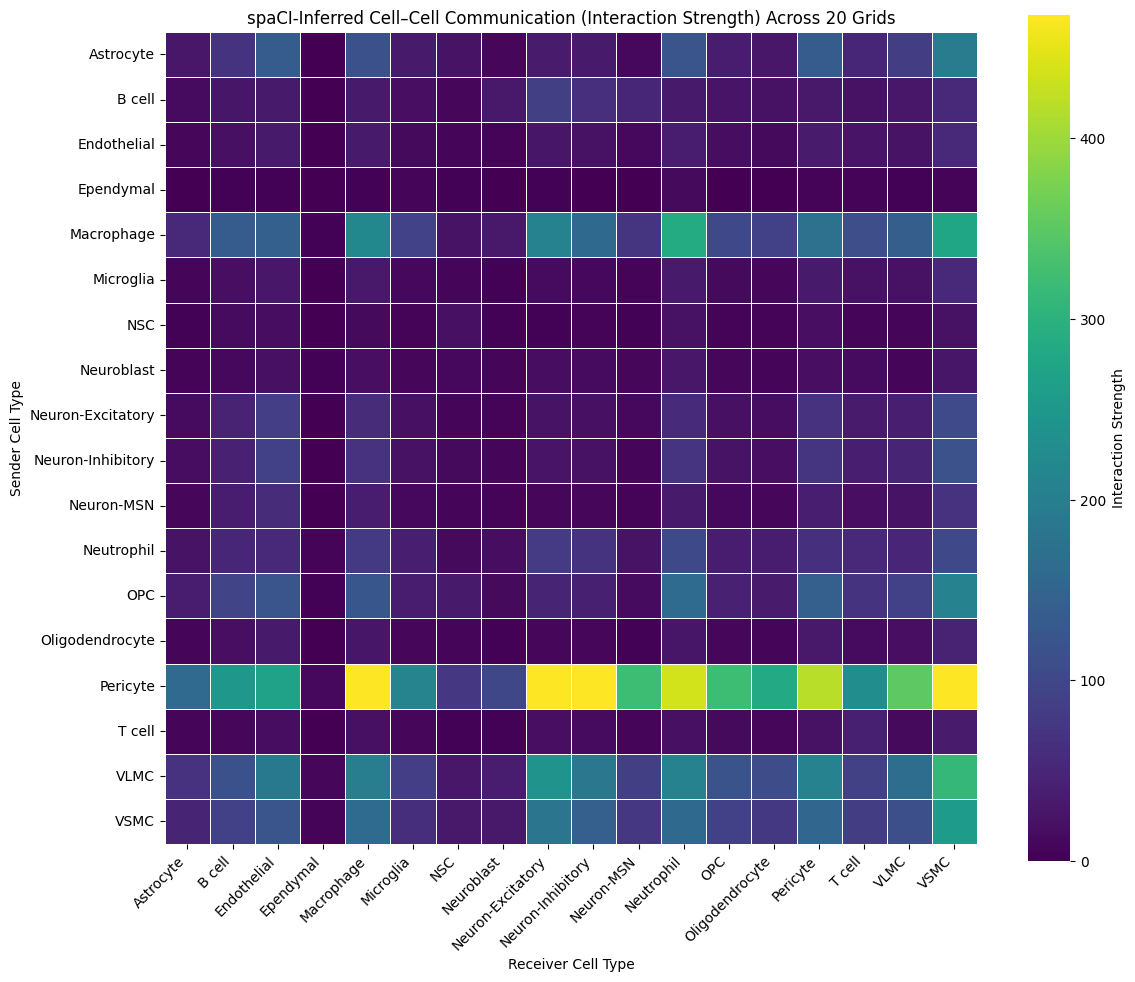

Saved Mean heatmap: /home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_Mean_heatmap_ALL_GRIDS.png


In [17]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    mean_matrix,
    cmap="viridis",
    vmin=0,
    vmax=mean_matrix.values.max() * 0.6,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Interaction Strength"}
)

plt.title("spaCI-Inferred Cell–Cell Communication (Interaction Strength) Across 20 Grids")
plt.xlabel("Receiver Cell Type")
plt.ylabel("Sender Cell Type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

Mean_heatmap_path = os.path.join(
    output_dir,
    "spaCI_Mean_heatmap_ALL_GRIDS.png"
)

plt.savefig(
    Mean_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved Mean heatmap:", Mean_heatmap_path)